# Lab 09. Nhận diện đối tượng qua Keypoint feature 
---
Dùng camera điện thoại chụp 20 ảnh trực diện gương mặt (J1). Sử dụng phương pháp crop ảnh chỉ tập trung vào gương mặt, xóa bỏ hậu kì, tóc... (J2).
1. Tách keypoint bằng các 04 phương pháp đã học.

2. Sử dụng mô hình SVM kết hợp với 4 dạng keypoint feature ở trên để huấn luyện mô hình ( 4 trained SVM tách biệt).

3. Chụp 1 ảnh mới và cũng chỉ tap trung vào gương mặt > tách keypoint theo các phương pháp ở trên > nhân diện đúng sai

In [33]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

BASE_DIR = Path.cwd()
if not (BASE_DIR / "data").exists():
    BASE_DIR = Path(r"d:\Code_learning\imageProcessing\lab9")

DATA_ROOT = BASE_DIR / "data"
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

TARGET_SIZE = 512
GRID_SIZE = 4
BORDER_RATIO = 0.03

CROP_TOP = 0.26
CROP_BOTTOM = 0.12
CROP_LEFT = 0.18
CROP_RIGHT = 0.18

SVM_NU = 0.03

FACE_CASCADE = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
assert not FACE_CASCADE.empty(), "Cannot load OpenCV face cascade."


In [34]:
def load_rgb(path):
    with Image.open(path) as image:
        return np.array(image.convert("RGB"))


def to_gray_uint8(image):
    if image.ndim == 2:
        gray = image
    else:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    if gray.dtype != np.uint8:
        gray = gray.astype(np.float32)
        if gray.max() <= 1.0:
            gray = gray * 255.0
        gray = np.clip(gray, 0, 255).astype(np.uint8)
    return gray


def to_gray_float(image):
    return to_gray_uint8(image).astype(np.float32) / 255.0


def detect_face_box(image):
    gray = to_gray_uint8(image)
    min_size = max(60, int(min(gray.shape[:2]) * 0.15))
    faces = FACE_CASCADE.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(min_size, min_size),
    )
    if len(faces) == 0:
        return None
    x, y, w, h = max(faces, key=lambda rect: rect[2] * rect[3])
    return int(x), int(y), int(w), int(h)


def crop_face(
    image,
    top_ratio=None,
    bottom_ratio=None,
    left_ratio=None,
    right_ratio=None,
):
    top_ratio = CROP_TOP if top_ratio is None else top_ratio
    bottom_ratio = CROP_BOTTOM if bottom_ratio is None else bottom_ratio
    left_ratio = CROP_LEFT if left_ratio is None else left_ratio
    right_ratio = CROP_RIGHT if right_ratio is None else right_ratio

    height, width = image.shape[:2]
    face_box = detect_face_box(image)

    if face_box is None:
        crop_height = int(height * 0.70)
        crop_width = int(width * 0.70)
        y1 = max(0, (height - crop_height) // 2)
        x1 = max(0, (width - crop_width) // 2)
        return image[y1 : y1 + crop_height, x1 : x1 + crop_width]

    x, y, face_width, face_height = face_box
    x1 = max(0, int(x + left_ratio * face_width))
    x2 = min(width, int(x + face_width - right_ratio * face_width))
    y1 = max(0, int(y + top_ratio * face_height))
    y2 = min(height, int(y + face_height - bottom_ratio * face_height))

    if x2 <= x1 or y2 <= y1:
        return image
    return image[y1:y2, x1:x2]


def preprocess_face(image, target_size=TARGET_SIZE):
    cropped = crop_face(image)
    if cropped.size == 0:
        cropped = image
    return cv2.resize(cropped, (target_size, target_size), interpolation=cv2.INTER_AREA)


def _empty_points():
    return np.empty((0, 2), dtype=np.int32), np.empty((0,), dtype=np.float32)


def _top_points(coords, scores, top_n):
    if coords.size == 0:
        return _empty_points()

    coords = np.asarray(coords, dtype=np.int32)
    scores = np.asarray(scores, dtype=np.float32)
    order = np.lexsort((coords[:, 1], coords[:, 0], -scores))
    if top_n is not None:
        order = order[:top_n]
    return coords[order], scores[order]


def fast_keypoints(image, threshold=50, nonmax=True, top_n=250):
    gray = to_gray_uint8(image)
    detector = cv2.FastFeatureDetector_create(
        threshold=threshold,
        nonmaxSuppression=nonmax,
    )
    keypoints = detector.detect(gray, None)
    if not keypoints:
        return _empty_points()

    coords = np.array(
        [[int(round(kp.pt[1])), int(round(kp.pt[0]))] for kp in keypoints],
        dtype=np.int32,
    )
    scores = np.array([float(kp.response) for kp in keypoints], dtype=np.float32)
    return _top_points(coords, scores, top_n)


def harris_keypoints(image, k=0.04, top_n=300, thresh_ratio=0.01):
    img_gray = to_gray_float(image)
    response = cv2.cornerHarris(img_gray, blockSize=2, ksize=3, k=k)

    response_thresh = response.copy()
    response_thresh[response_thresh < thresh_ratio * response_thresh.max()] = 0

    kernel = np.ones((3, 3), dtype=np.uint8)
    dilated = cv2.dilate(response_thresh, kernel)
    mask = (response_thresh == dilated) & (response_thresh > 0)
    coords = np.column_stack(np.nonzero(mask))
    if coords.size == 0:
        return _empty_points()

    scores = response[coords[:, 0], coords[:, 1]]
    return _top_points(coords, scores, top_n)


def gaussian_kernel(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1)
    g1d = np.exp(-(ax**2) / (2.0 * sigma**2))
    g1d /= g1d.sum()
    return np.outer(g1d, g1d).astype(np.float32)


def hessian_keypoints(image, sigma=2, top_n=600, thresh_ratio=0.05):
    img_gray = to_gray_float(image)

    size = int(10 * sigma + 1)
    if size % 2 == 0:
        size += 1

    g = gaussian_kernel(size, sigma)
    s = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)

    filter_xg = cv2.filter2D(
        cv2.filter2D(g, -1, s.T, borderType=cv2.BORDER_REPLICATE),
        -1,
        s.T,
        borderType=cv2.BORDER_REPLICATE,
    )
    filter_yg = cv2.filter2D(
        cv2.filter2D(g, -1, s, borderType=cv2.BORDER_REPLICATE),
        -1,
        s,
        borderType=cv2.BORDER_REPLICATE,
    )
    filter_xyg = cv2.filter2D(
        cv2.filter2D(g, -1, s.T, borderType=cv2.BORDER_REPLICATE),
        -1,
        s,
        borderType=cv2.BORDER_REPLICATE,
    )

    img_dxx = cv2.filter2D(img_gray, -1, filter_xg, borderType=cv2.BORDER_REPLICATE)
    img_dyy = cv2.filter2D(img_gray, -1, filter_yg, borderType=cv2.BORDER_REPLICATE)
    img_dxy = cv2.filter2D(img_gray, -1, filter_xyg, borderType=cv2.BORDER_REPLICATE)
    response = img_dxx * img_dyy - img_dxy**2

    response_thresh = response.copy()
    response_thresh[response_thresh < thresh_ratio * response_thresh.max()] = 0

    kernel = np.ones((3, 3), dtype=np.uint8)
    dilated = cv2.dilate(response_thresh, kernel)
    mask = (response_thresh == dilated) & (response_thresh > 0)
    coords = np.column_stack(np.nonzero(mask))
    if coords.size == 0:
        return _empty_points()

    scores = response[coords[:, 0], coords[:, 1]]
    return _top_points(coords, scores, top_n)


def laplacian_keypoints(image, sigma=4, top_n=900, thresh_ratio=0.35):
    img_gray = to_gray_float(image)

    ksize = int(3 * sigma + 1)
    if ksize % 2 == 0:
        ksize += 1

    blurred = cv2.GaussianBlur(
        img_gray,
        (ksize, ksize),
        sigmaX=sigma,
        sigmaY=sigma,
        borderType=cv2.BORDER_REPLICATE,
    )
    response = cv2.Laplacian(
        blurred,
        cv2.CV_32F,
        ksize=3,
        borderType=cv2.BORDER_REPLICATE,
    )

    response_abs = np.abs(response)
    thresh = thresh_ratio * np.max(response_abs)
    response_thresh = response.copy()
    response_thresh[response_abs < thresh] = 0

    kernel = np.ones((3, 3), dtype=np.uint8)
    max_pos = cv2.dilate(response_thresh, kernel)
    max_neg = cv2.dilate(-response_thresh, kernel)
    mask = ((response_thresh == max_pos) & (response_thresh > 0)) | (
        (-response_thresh == max_neg) & (response_thresh < 0)
    )

    coords = np.column_stack(np.nonzero(mask))
    if coords.size == 0:
        return _empty_points()

    border = int(max(1, sigma))
    valid = (
        (coords[:, 0] > border)
        & (coords[:, 0] < img_gray.shape[0] - border)
        & (coords[:, 1] > border)
        & (coords[:, 1] < img_gray.shape[1] - border)
    )
    coords = coords[valid]
    if coords.size == 0:
        return _empty_points()

    scores = np.abs(response[coords[:, 0], coords[:, 1]])
    return _top_points(coords, scores, top_n)


def filter_interior_points(coords, scores, image_shape, border_ratio=BORDER_RATIO):
    if coords.size == 0:
        return _empty_points()

    height, width = image_shape[:2]
    border = max(1, int(border_ratio * min(height, width)))
    valid = (
        (coords[:, 0] >= border)
        & (coords[:, 0] < height - border)
        & (coords[:, 1] >= border)
        & (coords[:, 1] < width - border)
    )
    coords = coords[valid]
    scores = scores[valid]
    if coords.size == 0:
        return _empty_points()
    return coords, scores


def keypoint_feature_vector(image, detector_fn, grid_size=GRID_SIZE):
    processed = preprocess_face(image)
    coords, scores = detector_fn(processed)
    coords, scores = filter_interior_points(coords, scores, processed.shape)

    height, width = processed.shape[:2]
    feature_count = grid_size * grid_size + 7
    if coords.size == 0:
        return np.zeros(feature_count, dtype=np.float32)

    ys = coords[:, 0].astype(np.float32) / max(1, height - 1)
    xs = coords[:, 1].astype(np.float32) / max(1, width - 1)
    histogram, _, _ = np.histogram2d(
        ys,
        xs,
        bins=grid_size,
        range=[[0.0, 1.0], [0.0, 1.0]],
    )
    histogram = histogram.astype(np.float32).ravel()
    histogram /= max(1.0, histogram.sum())

    stats = np.array(
        [
            len(coords) / float(height * width),
            xs.mean(),
            ys.mean(),
            xs.std(),
            ys.std(),
            float(scores.mean()) if scores.size else 0.0,
            float(scores.std()) if scores.size else 0.0,
        ],
        dtype=np.float32,
    )
    return np.concatenate([histogram, stats]).astype(np.float32)


def draw_keypoints(image, detector_fn):
    coords, scores = detector_fn(image)
    coords, scores = filter_interior_points(coords, scores, image.shape)
    overlay = image.copy()
    for y, x in coords:
        cv2.drawMarker(
            overlay,
            (int(x), int(y)),
            (0, 255, 255),
            markerType=cv2.MARKER_CROSS,
            markerSize=8,
            thickness=1,
        )
    return overlay, len(coords)


def build_feature_matrix(image_paths, detector_fn):
    return np.vstack([keypoint_feature_vector(load_rgb(path), detector_fn) for path in image_paths])


def train_one_class_model(X_train):
    model = make_pipeline(
        StandardScaler(),
        OneClassSVM(kernel="rbf", nu=SVM_NU, gamma="scale"),
    )
    model.fit(X_train)
    return model


In [35]:
def load_gray(path):
    with Image.open(path) as image:
        return np.array(image.convert("L"))


load_rgb = load_gray


def visualize(items, cols=2, figsize=None):
    if not items:
        return None

    rows = (len(items) + cols - 1) // cols
    if figsize is None:
        figsize = (5 * cols, 5 * rows)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for axis, (title, image) in zip(axes, items):
        if image.ndim == 2:
            axis.imshow(image, cmap="gray")
        else:
            axis.imshow(image)
        axis.set_title(title)
        axis.axis("off")

    for axis in axes[len(items):]:
        axis.axis("off")

    fig.tight_layout()
    plt.show()
    return None


def draw_keypoints(image, detector_fn):
    gray = to_gray_uint8(image)
    coords, scores = detector_fn(gray)
    coords, scores = filter_interior_points(coords, scores, gray.shape)

    overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    for y, x in coords:
        cv2.drawMarker(
            overlay,
            (int(x), int(y)),
            (0, 255, 255),
            markerType=cv2.MARKER_CROSS,
            markerSize=8,
            thickness=1,
        )
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB), len(coords)


## 0. Chuẩn bị dữ liệu và crop khuôn mặt

Phần này nạp danh sách ảnh train/test, kiểm tra crop trên một ảnh mẫu, và dùng cùng một hàm crop cho cả train lẫn test.

Train images: 20
Test image: test_01.jpg
Crop ratios: top=0.26, bottom=0.12, left=0.18, right=0.18
Face crop size after resize: 512 x 512


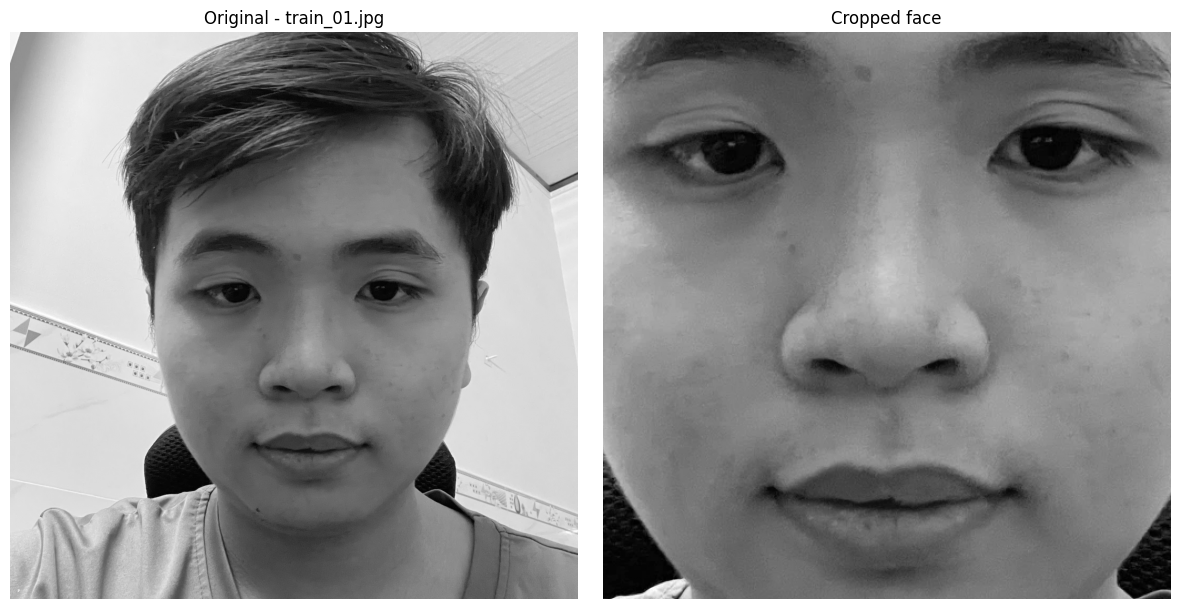

In [36]:
train_paths = sorted(TRAIN_DIR.glob("*.jpg"))
test_paths = sorted(TEST_DIR.glob("*.jpg"))
assert len(train_paths) == 20, f"Expected 20 train images, got {len(train_paths)}"
assert len(test_paths) == 1, f"Expected 1 test image, got {len(test_paths)}"

sample_path = train_paths[0]
sample_original = load_gray(sample_path)
sample_cropped = preprocess_face(sample_original)

print(f"Train images: {len(train_paths)}")
print(f"Test image: {test_paths[0].name}")
print(f"Crop ratios: top={CROP_TOP}, bottom={CROP_BOTTOM}, left={CROP_LEFT}, right={CROP_RIGHT}")
print(f"Face crop size after resize: {TARGET_SIZE} x {TARGET_SIZE}")

visualize(
    [
        (f"Original - {sample_path.name}", sample_original),
        ("Cropped face", sample_cropped),
    ],
    cols=2,
    figsize=(12, 6),
)

## 1. Tách keypoint bằng các 04 phương pháp đã học.

Dùng ảnh mặt đã crop ở bước trước để quan sát 4 nhóm keypoint: FAST, Harris, Hessian và Laplacian.

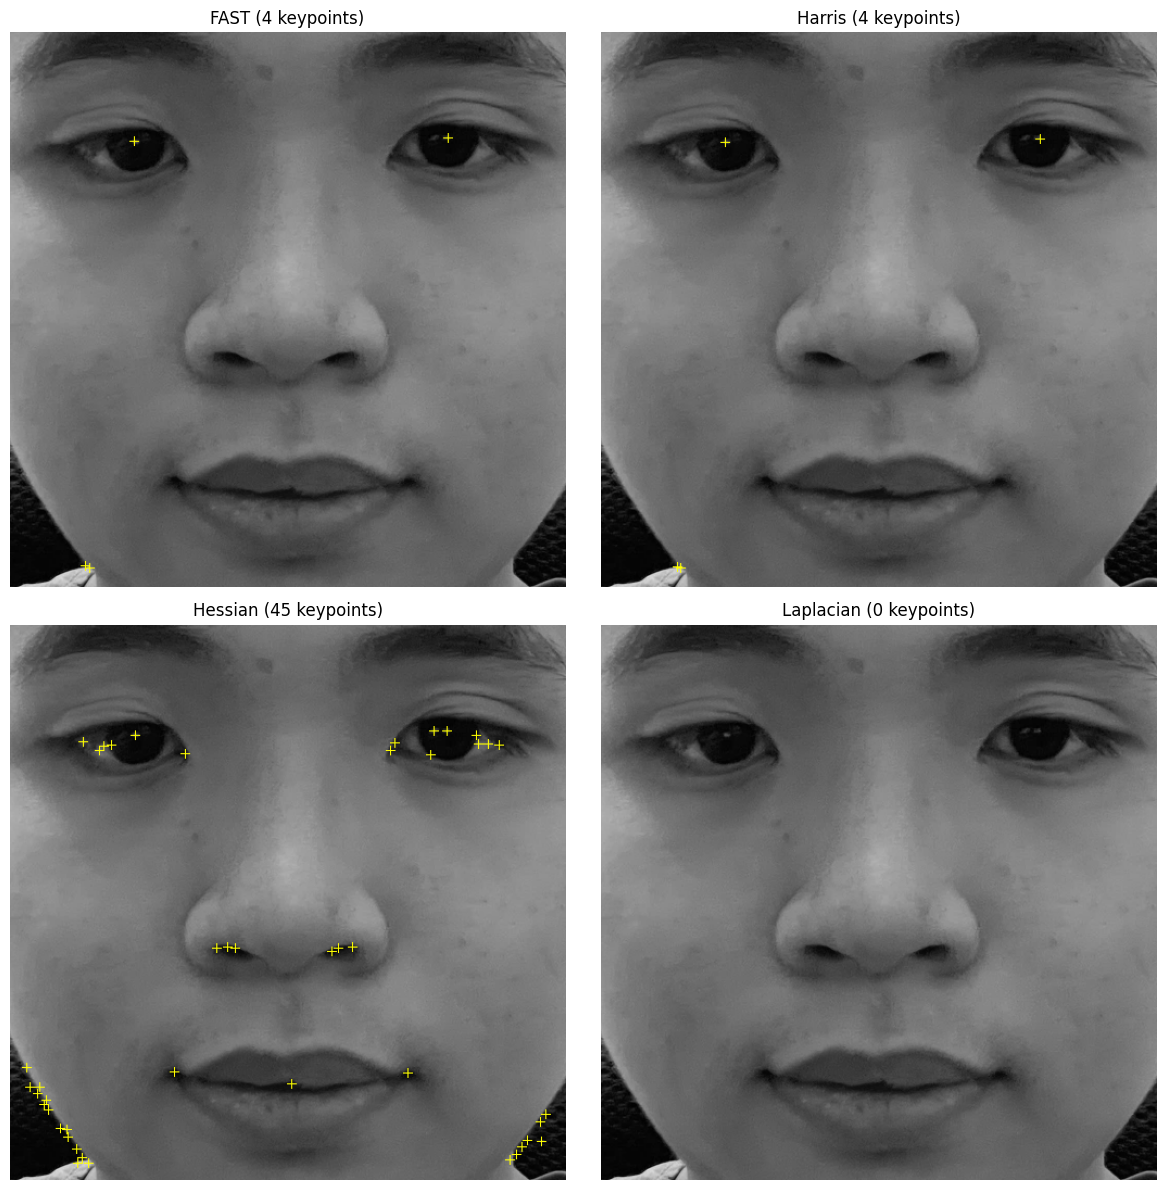

In [37]:
fast_overlay, fast_count = draw_keypoints(sample_cropped, fast_keypoints)
harris_overlay, harris_count = draw_keypoints(sample_cropped, harris_keypoints)
hessian_overlay, hessian_count = draw_keypoints(sample_cropped, hessian_keypoints)
laplacian_overlay, laplacian_count = draw_keypoints(sample_cropped, laplacian_keypoints)

visualize(
    [
        (f"FAST ({fast_count} keypoints)", fast_overlay),
        (f"Harris ({harris_count} keypoints)", harris_overlay),
        (f"Hessian ({hessian_count} keypoints)", hessian_overlay),
        (f"Laplacian ({laplacian_count} keypoints)", laplacian_overlay),
    ],
    cols=2,
    figsize=(12, 12),
)

## 2. Sử dụng mô hình SVM kết hợp với 4 dạng keypoint feature ở trên để huấn luyện mô hình.

Huấn luyện 4 mô hình One-Class SVM tách biệt, mỗi mô hình ứng với một bộ keypoint feature.

In [38]:
fast_train_features = build_feature_matrix(train_paths, fast_keypoints)
harris_train_features = build_feature_matrix(train_paths, harris_keypoints)
hessian_train_features = build_feature_matrix(train_paths, hessian_keypoints)
laplacian_train_features = build_feature_matrix(train_paths, laplacian_keypoints)

fast_model = train_one_class_model(fast_train_features)
harris_model = train_one_class_model(harris_train_features)
hessian_model = train_one_class_model(hessian_train_features)
laplacian_model = train_one_class_model(laplacian_train_features)

train_runs = [
    ("FAST", fast_train_features, fast_model),
    ("Harris", harris_train_features, harris_model),
    ("Hessian", hessian_train_features, hessian_model),
    ("Laplacian", laplacian_train_features, laplacian_model),
]

training_results = []
for name, train_features, model in train_runs:
    train_pred = model.predict(train_features)
    train_accept_rate = float((train_pred == 1).mean())
    training_results.append((name, train_accept_rate, int(len(train_features))))
    print(f"{name:<10s} | train accept = {train_accept_rate:.2f} | model trained")

print("-")
print(f"Trained {len(train_runs)} separate One-Class SVM models.")

FAST       | train accept = 0.90 | model trained
Harris     | train accept = 0.40 | model trained
Hessian    | train accept = 0.60 | model trained
Laplacian  | train accept = 0.25 | model trained
-
Trained 4 separate One-Class SVM models.


## 3. Chụp 1 ảnh mới và tách keypoint theo các phương pháp ở trên để nhận diện đúng sai.

Dùng ảnh test đã cho sẵn để kiểm tra từng mô hình và lấy kết luận cuối cùng bằng đa số phiếu.

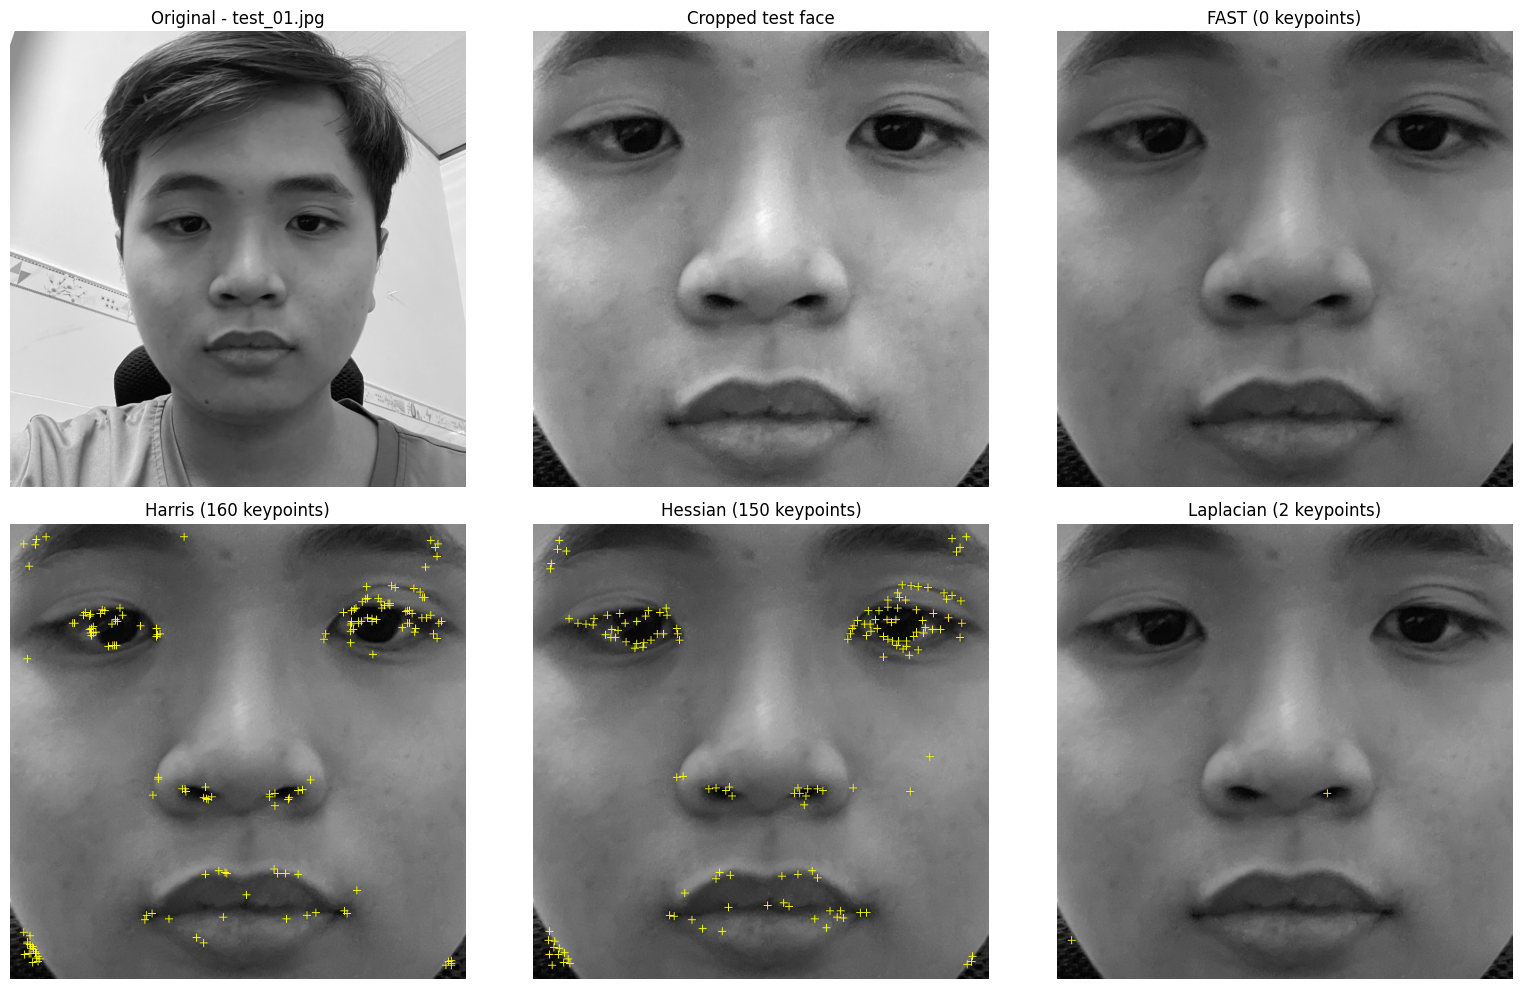

FAST       | test score =  0.0000 | verdict = DUNG
Harris     | test score =  0.0044 | verdict = DUNG
Hessian    | test score = -0.0041 | verdict = SAI
Laplacian  | test score = -0.0326 | verdict = SAI
-
Majority vote: 2/4 models accept the test image
Average decision score: -0.0081
Final verdict: SAI


In [39]:
test_image = load_gray(test_paths[0])
test_cropped = preprocess_face(test_image)

fast_test_features = keypoint_feature_vector(test_image, fast_keypoints)[None, :]
harris_test_features = keypoint_feature_vector(test_image, harris_keypoints)[None, :]
hessian_test_features = keypoint_feature_vector(test_image, hessian_keypoints)[None, :]
laplacian_test_features = keypoint_feature_vector(test_image, laplacian_keypoints)[None, :]

fast_test_overlay, fast_test_count = draw_keypoints(test_cropped, fast_keypoints)
harris_test_overlay, harris_test_count = draw_keypoints(test_cropped, harris_keypoints)
hessian_test_overlay, hessian_test_count = draw_keypoints(test_cropped, hessian_keypoints)
laplacian_test_overlay, laplacian_test_count = draw_keypoints(test_cropped, laplacian_keypoints)

visualize(
    [
        (f"Original - {test_paths[0].name}", test_image),
        ("Cropped test face", test_cropped),
        (f"FAST ({fast_test_count} keypoints)", fast_test_overlay),
        (f"Harris ({harris_test_count} keypoints)", harris_test_overlay),
        (f"Hessian ({hessian_test_count} keypoints)", hessian_test_overlay),
        (f"Laplacian ({laplacian_test_count} keypoints)", laplacian_test_overlay),
    ],
    cols=3,
    figsize=(16, 10),
)

final_results = []
for name, model, test_features in [
    ("FAST", fast_model, fast_test_features),
    ("Harris", harris_model, harris_test_features),
    ("Hessian", hessian_model, hessian_test_features),
    ("Laplacian", laplacian_model, laplacian_test_features),
]:
    test_pred = int(model.predict(test_features)[0])
    test_score = float(model.decision_function(test_features)[0])
    final_results.append((name, test_pred, test_score))

    verdict = "DUNG" if test_pred == 1 else "SAI"
    print(f"{name:<10s} | test score = {test_score: .4f} | verdict = {verdict}")

votes = sum(test_pred == 1 for _, test_pred, _ in final_results)
mean_score = float(np.mean([test_score for _, _, test_score in final_results]))
if votes >= 3:
    overall = "DUNG"
elif votes <= 1:
    overall = "SAI"
else:
    overall = "DUNG" if mean_score > 0 else "SAI"

print("-")
print(f"Majority vote: {votes}/4 models accept the test image")
print(f"Average decision score: {mean_score: .4f}")
print(f"Final verdict: {overall}")